# 01_EDA.ipynb

**Objetivo:** Foco en análisis exploratorio, carga de data/raw, limpieza usando src.preprocessing y guardado del set final en data/processed.

In [3]:
import sys
import os
import pandas as pd

# Agregar la ruta a la carpeta src para poder importar los módulos módulos desarrollados
sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_datos, create_target_classes
from src.evaluation import evaluar_modelo

# Definición de rutas base a los archivos de datos 
RAW_DATA_PATH_1 = '../data/raw/BD_IPSA_1940.xlsx'
RAW_DATA_PATH_2 = '../data/raw/HISTORICO_SUERTES.xlsx'
PROCESSED_DATA_PATH = '../data/processed/datos_limpios_modelo.csv'


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df_reg = pd.read_excel('../data/raw/HISTORICO_SUERTES.xlsx')
df_clf = pd.read_excel('../data/raw/BD_IPSA_1940.xlsx')

# Vista general
print("REGRESIÓN")
print(df_reg.shape)
print(df_reg.info())
print(df_reg.head())

print("\nCLASIFICACIÓN")
print(df_clf.shape)
print(df_clf.info())
print(df_clf.head())

REGRESIÓN
(21027, 85)
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Período                    21027 non-null  int64         
 1   Hacienda                   21027 non-null  int64         
 2   Nombre                     21027 non-null  str           
 3   Zona                       21027 non-null  str           
 4   Tenencia                   21026 non-null  float64       
 5   Suerte                     21027 non-null  str           
 6   Suelo                      17269 non-null  str           
 7   Area Neta                  21027 non-null  float64       
 8   Dist Km                    21022 non-null  float64       
 9   Variedad                   21027 non-null  str           
 10  Cod.Estado #               21027 non-null  int64         
 11  Cod.Estado                 21027 non-null  str          

In [10]:
# Eliminar columnas totalmente vacías
df_reg = df_reg.dropna(axis=1, how='all')
df_clf = df_clf.dropna(axis=1, how='all')

# Eliminar columnas irrelevantes tipo índice
df_clf = df_clf.drop(columns=['Unnamed: 0'], errors='ignore')
df_reg = df_reg.drop(columns=['Unnamed: 0'], errors='ignore')

print("Columnas finales en regresión:", df_reg.shape[1])
print("Columnas finales en clasificación:", df_clf.shape[1])

Columnas finales en regresión: 83
Columnas finales en clasificación: 20


In [12]:
variables_reg = [
    'Edad Ult Cos',
    'Variedad',
    'Suelo',
    'Dist Km',
    'Dosis Madurante',
    'Semanas mad.'
]

target_reg = ['TCH', '%Sac.Caña']

print("Variables predictoras regresión:", variables_reg)
print("Variables objetivo regresión:", target_reg)

Variables predictoras regresión: ['Edad Ult Cos', 'Variedad', 'Suelo', 'Dist Km', 'Dosis Madurante', 'Semanas mad.']
Variables objetivo regresión: ['TCH', '%Sac.Caña']


**¿Qué variables se seleccionan en regresión y por qué?**

Para regresión se eligieron Edad Ult Cos, Variedad, Suelo, Dist Km, Dosis Madurante y Semanas mad. porque tienen relación agronómica con el rendimiento y la calidad:

- Edad Ult Cos: la edad del cultivo influye directamente en la acumulación de biomasa.
- Variedad: representa diferencias genéticas en potencial productivo y contenido de sacarosa.
- Suelo: afecta disponibilidad de nutrientes, drenaje y retención de humedad.
- Dist Km: puede reflejar condiciones logísticas y oportunidad de cosecha.
- Dosis Madurante: influye en el proceso de acumulación de sacarosa.
- Semanas mad.: representa tiempo efectivo de maduración, clave para calidad industrial.

**Variables descartadas en regresión**

Se descartan variables como:
Nombre, Suerte, Hacienda, Cod.Estado, Cod.Estado #: actúan como identificadores y no aportan capacidad predictiva generalizable.
Fechas crudas como F.Siembra o F.Ult.Corte: son más útiles si se transforman en edad o duración, pero no necesariamente como fecha sin procesar.
Variables con altísimo porcentaje de faltantes: por ejemplo Fert.Nitrogen., Urea 46%, NITRAX-S, MEZ, variables climáticas con muy baja cobertura y otras similares.

In [13]:
variables_clf = [
    'variedad',
    'edad',
    'cortes',
    'lluvias',
    'grupo_tenencia',
    'pct_diatrea'
]

print("Variables predictoras clasificación:", variables_clf)

Variables predictoras clasificación: ['variedad', 'edad', 'cortes', 'lluvias', 'grupo_tenencia', 'pct_diatrea']


**¿Qué variables se seleccionan en clasificación y por qué?**

Para clasificación se eligieron:
variedad: representa diferencias genéticas del cultivo.
edad: influye sobre el nivel de desarrollo y rendimiento.
cortes: el número de cortes afecta el vigor de la caña y su productividad.
lluvias: refleja disponibilidad hídrica.
grupo_tenencia: puede asociarse con condiciones de manejo y tipo de explotación.
pct_diatrea: indicador fitosanitario, relevante para pérdidas de rendimiento.

**Variables descartadas en clasificación**

Se descartan:
NOME, FAZ, TAL: identificadores o referencias administrativas.
TCH y sacarosa como predictores: no deben entrar en X porque se usarán para construir la variable objetivo Clase; incluirlas produciría fuga de información.
producto y madurada podrían explorarse, pero se prefirió un conjunto más compacto y explicable para el modelo inicial.

In [14]:
# Crear target de clasificación usando TCH y sacarosa
df_clf['Clase'] = np.where(
    (df_clf['TCH'] > df_clf['TCH'].median()) &
    (df_clf['sacarosa'] > df_clf['sacarosa'].median()),
    'Alta',
    'Baja'
)

print(df_clf['Clase'].value_counts())

Clase
Baja    1769
Alta     418
Name: count, dtype: int64


En clasificación, la variable objetivo no viene dada directamente. Por eso se construye Clase a partir de TCH y sacarosa, clasificando como Alta los casos con rendimiento y calidad por encima de la mediana, y como Baja el resto.

In [15]:
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100
missing_clf = df_clf.isnull().mean().sort_values(ascending=False) * 100

print("Porcentaje de valores faltantes - Regresión")
print(missing_reg)

print("\nPorcentaje de valores faltantes - Clasificación")
print(missing_clf)

Porcentaje de valores faltantes - Regresión
Urea 46%                  96.561564
NITRAX-S                  96.442669
MEZ                       95.382128
MicroZinc                 94.535597
Boro Granul.              93.888810
                            ...    
DDUlt.Riego                0.000000
Lluvias seis a nueve       0.000000
Lluvias tres a seis        0.000000
Luvias 9 -FC               0.000000
Lluvias (2 Meses Ant.)     0.000000
Length: 83, dtype: float64

Porcentaje de valores faltantes - Clasificación
NOME              0.0
FAZ               0.0
TAL               0.0
tipocorte         0.0
variedad          0.0
madurada          0.0
producto          0.0
dosismad          0.0
semsmad           0.0
edad              0.0
cortes            0.0
me                0.0
vejez             0.0
sacarosa          0.0
mes               0.0
periodo           0.0
TCH               0.0
lluvias           0.0
grupo_tenencia    0.0
pct_diatrea       0.0
Clase             0.0
dtype: float64


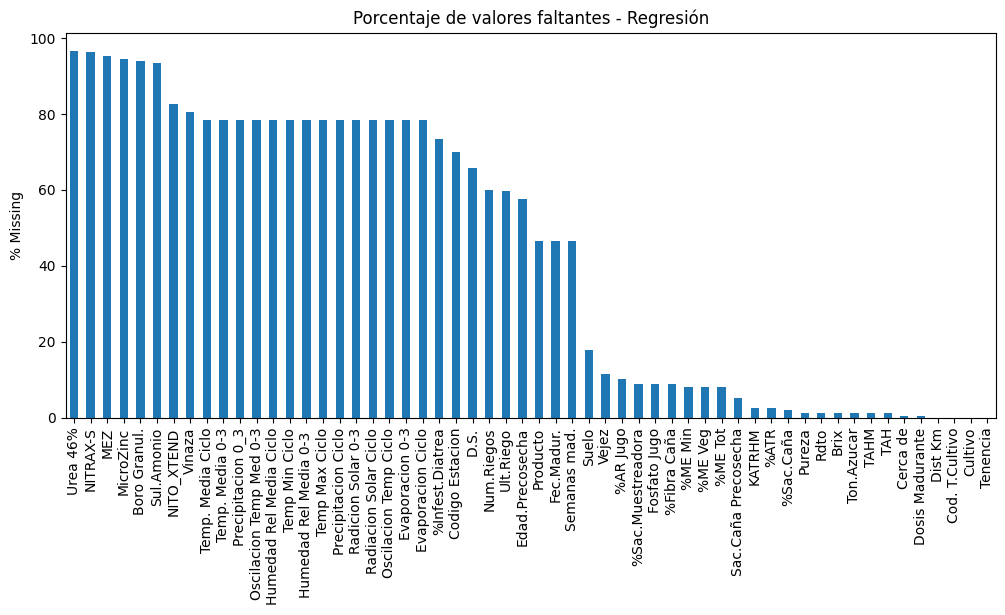

En el dataset de clasificación no hay valores faltantes en las columnas analizadas.


<Figure size 1200x500 with 0 Axes>

In [16]:
# Solo mostrar columnas con missing > 0 para no generar gráficas vacías
missing_reg_plot = missing_reg[missing_reg > 0]
missing_clf_plot = missing_clf[missing_clf > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))
if len(missing_clf_plot) > 0:
    missing_clf_plot.plot(kind='bar')
    plt.title('Porcentaje de valores faltantes - Clasificación')
    plt.ylabel('% Missing')
    plt.show()
else:
    print("En el dataset de clasificación no hay valores faltantes en las columnas analizadas.")

In [17]:
# Detectar columnas con alto missing en regresión
cols_drop_reg = missing_reg[missing_reg > 50].index.tolist()

print("Columnas con más de 50% de missing en regresión:")
print(cols_drop_reg)

Columnas con más de 50% de missing en regresión:
['Urea 46%', 'NITRAX-S', 'MEZ', 'MicroZinc', 'Boro Granul.', 'Sul.Amonio', 'NITO_XTEND', 'Vinaza', 'Temp. Media Ciclo', 'Temp. Media 0-3', 'Precipitacion 0_3', 'Oscilacion Temp Med 0-3', 'Humedad Rel Media Ciclo', 'Temp Min Ciclo', 'Humedad Rel Media 0-3 ', 'Temp Max Ciclo', 'Precipitacion Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Oscilacion Temp Ciclo', 'Evaporacion 0-3', 'Evaporacion Ciclo', '%Infest.Diatrea', 'Codigo Estacion', 'D.S.', 'Num.Riegos', 'Ult.Riego', 'Edad.Precosecha']


**¿Qué estrategia de imputación se propone?**

**Para regresión:**
Variables numéricas con pocos faltantes: imputación por mediana, porque es robusta frente a outliers.
Variables categóricas con pocos faltantes: imputación por moda.
Dosis Madurante: si desde el negocio se interpreta que vacío equivale a “no aplicado”, puede imputarse con 0.
Variables con más del 50% de faltantes: descartar, ya que imputarlas introduciría demasiada incertidumbre.
Variables climáticas o de contexto: idealmente podrían imputarse por medias agrupadas por Zona, Período o Codigo Estacion, si se quisiera un tratamiento más fino.

**Para clasificación:**
Como las variables seleccionadas no presentan faltantes, no se requiere imputación para el conjunto base del modelo. Si aparecieran nulos en una versión posterior:
numéricas: mediana
categóricas: moda

**Qué hacer con variables con alto porcentaje de datos faltantes?**

Es preferible descartarlas cuando el porcentaje de faltantes es muy alto, especialmente por encima de 50%. Imputarlas conlleva un alto grado de incertidumbre y puede empeorar la calidad del análisis y del modelo. En regresión esto aplica a varias variables de fertilización y clima de baja cobertura.

In [18]:
from sklearn.impute import SimpleImputer

df_reg_eda = df_reg[variables_reg + target_reg].copy()
df_clf_eda = df_clf[variables_clf + ['Clase', 'TCH', 'sacarosa']].copy()

# Imputación simple para EDA en variables predictoras de regresión
num_cols_reg = df_reg_eda[variables_reg].select_dtypes(include=np.number).columns
cat_cols_reg = df_reg_eda[variables_reg].select_dtypes(exclude=np.number).columns

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

df_reg_eda[num_cols_reg] = imputer_num.fit_transform(df_reg_eda[num_cols_reg])
df_reg_eda[cat_cols_reg] = imputer_cat.fit_transform(df_reg_eda[cat_cols_reg])

# La target de regresión no se imputa: se eliminan filas faltantes en target para análisis/modelado posterior
df_reg_eda = df_reg_eda.dropna(subset=target_reg)

print(df_reg_eda.isnull().sum())

Edad Ult Cos       0
Variedad           0
Suelo              0
Dist Km            0
Dosis Madurante    0
Semanas mad.       0
TCH                0
%Sac.Caña          0
dtype: int64


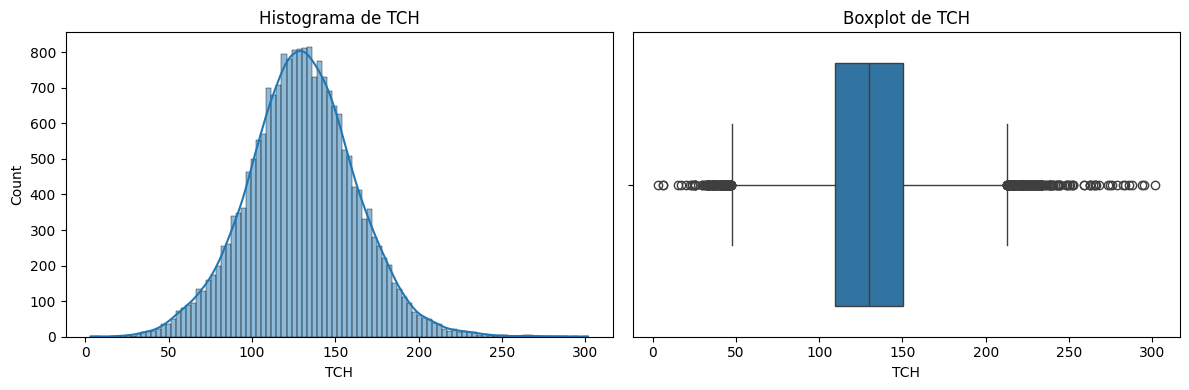

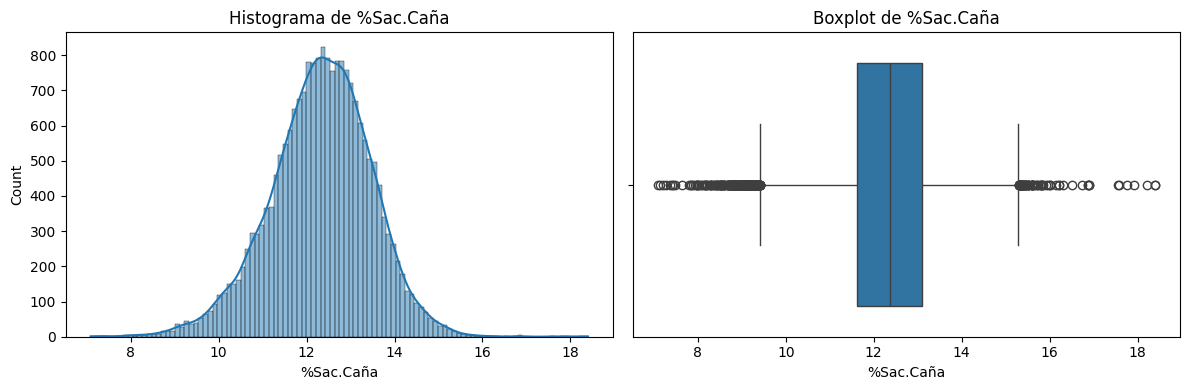

In [19]:
for col in ['TCH', '%Sac.Caña']:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df_reg_eda[col].dropna(), kde=True)
    plt.title(f'Histograma de {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_reg_eda[col].dropna())
    plt.title(f'Boxplot de {col}')

    plt.tight_layout()
    plt.show()

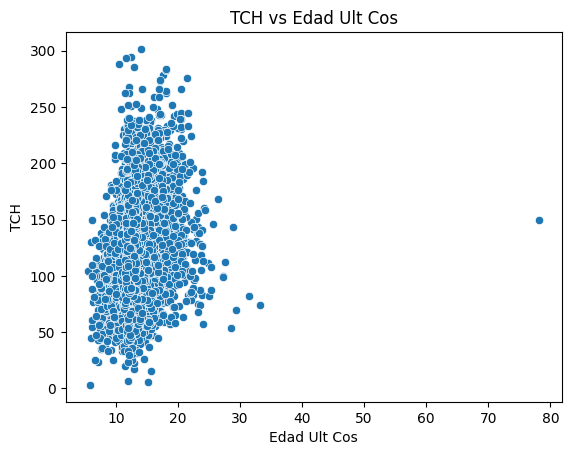

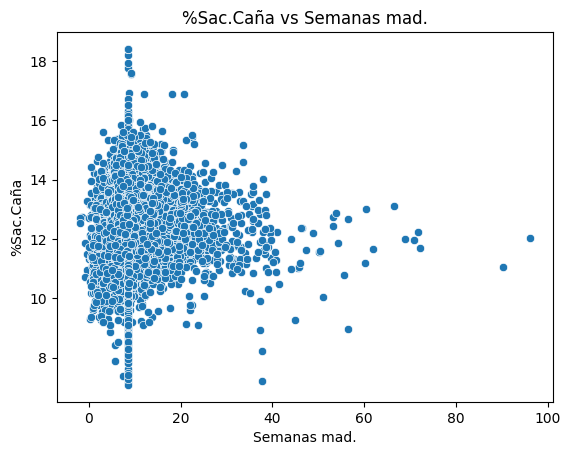

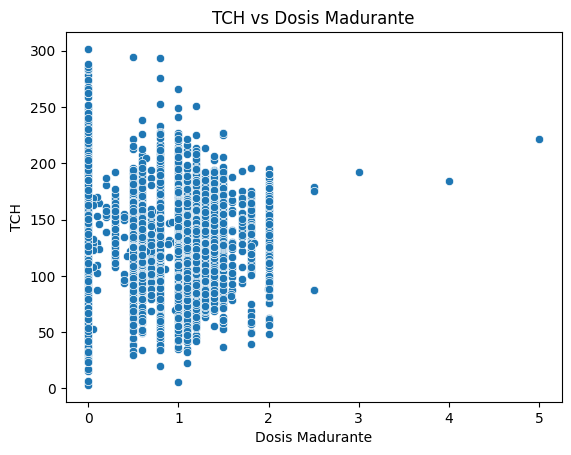

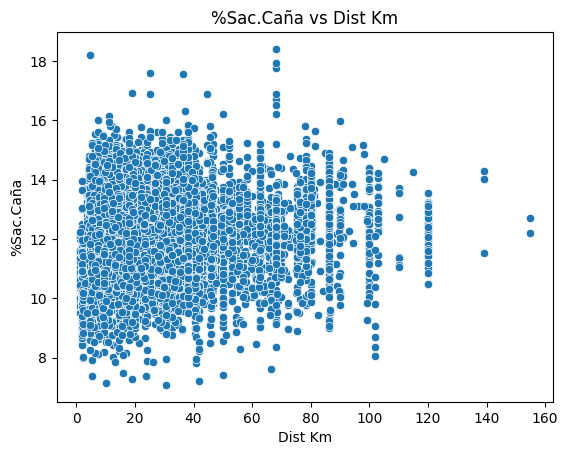

In [20]:
# Dispersión TCH vs Edad
sns.scatterplot(data=df_reg_eda, x='Edad Ult Cos', y='TCH')
plt.title('TCH vs Edad Ult Cos')
plt.show()

# Dispersión %Sac.Caña vs Semanas de maduración
sns.scatterplot(data=df_reg_eda, x='Semanas mad.', y='%Sac.Caña')
plt.title('%Sac.Caña vs Semanas mad.')
plt.show()

# Dispersión TCH vs Dosis Madurante
sns.scatterplot(data=df_reg_eda, x='Dosis Madurante', y='TCH')
plt.title('TCH vs Dosis Madurante')
plt.show()

# Dispersión %Sac.Caña vs Dist Km
sns.scatterplot(data=df_reg_eda, x='Dist Km', y='%Sac.Caña')
plt.title('%Sac.Caña vs Dist Km')
plt.show()

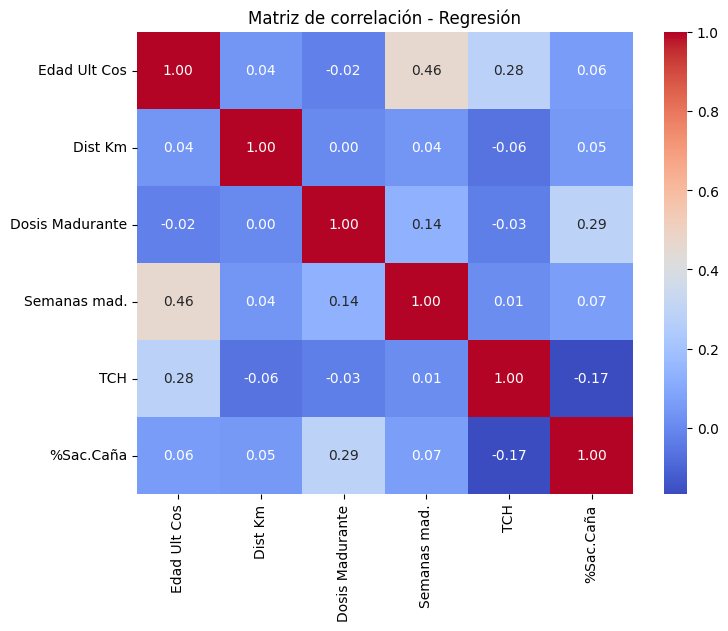

                 Edad Ult Cos   Dist Km  Dosis Madurante  Semanas mad.  \
Edad Ult Cos         1.000000  0.040455        -0.023300      0.460731   
Dist Km              0.040455  1.000000         0.003905      0.040700   
Dosis Madurante     -0.023300  0.003905         1.000000      0.136194   
Semanas mad.         0.460731  0.040700         0.136194      1.000000   
TCH                  0.280524 -0.062320        -0.027912      0.013118   
%Sac.Caña            0.059867  0.048014         0.287065      0.068281   

                      TCH  %Sac.Caña  
Edad Ult Cos     0.280524   0.059867  
Dist Km         -0.062320   0.048014  
Dosis Madurante -0.027912   0.287065  
Semanas mad.     0.013118   0.068281  
TCH              1.000000  -0.168060  
%Sac.Caña       -0.168060   1.000000  


In [21]:
cols_corr = ['Edad Ult Cos', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'TCH', '%Sac.Caña']

corr_matrix = df_reg_eda[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación - Regresión')
plt.show()

print(corr_matrix)

In [23]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_reg_eda[['Edad Ult Cos', 'Dist Km', 'Dosis Madurante', 'Semanas mad.']].copy()

X_vif = X_vif.dropna()

X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

          Variable        VIF
0            const  51.330011
1     Edad Ult Cos   1.282517
2          Dist Km   1.002260
3  Dosis Madurante   1.028753
4     Semanas mad.   1.306045


## Preparación de Datos para Clasificación

A partir de aquí usamos las funciones de `src/preprocessing.py` para:
1. **Imputar** valores nulos con reglas de negocio.
2. **Crear la variable objetivo** en tres clases balanceadas (`Bajo`, `Medio`, `Alto`) usando `TCH`.
3. **Codificar** las variables categóricas.
4. **Exportar** el dataset limpio a `data/processed/datos_limpios_modelo.csv`.

In [25]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_datos, create_target_classes, apply_label_encoder


In [26]:
# Variables seleccionadas para clasificación ~ predictores agrónomicos
variables_clf = [
    'variedad',
    'edad',
    'cortes',
    'lluvias',
    'grupo_tenencia',
    'pct_diatrea',
    'dosismad',   # dosismad se imputará con 0 ~ regla de negocio
    'semsmad',
    'me',
    'vejez',
]

# Target y columnas sensibles que NO van como predictores
target_col = 'TCH'

# Subconjunto del dataset original (predictores + target)
cols_to_keep = variables_clf + [target_col, 'sacarosa']
df_clf_model = df_clf[cols_to_keep].copy()

print(f"Shape antes de imputar: {df_clf_model.shape}")
print(f"Nulos antes:\n{df_clf_model.isnull().sum()[df_clf_model.isnull().sum() > 0]}")

# Imputación con reglas de negocio
df_clf_model = imputar_datos(df_clf_model)

print(f"\nNulos después de imputar: {df_clf_model.isnull().sum().sum()}")


Shape antes de imputar: (2187, 12)
Nulos antes:
Series([], dtype: int64)

Nulos después de imputar: 0


In [27]:
# Crear variable objetivo en 3 clases balanceadas
df_clf_model = create_target_classes(df_clf_model, target_col='TCH')
print("Distribución de clases:")
print(df_clf_model['Clase_Objetivo'].value_counts())

# Codificación de variables categóricas con LabelEncoder
cat_cols = ['variedad']
df_clf_model, encoders = apply_label_encoder(df_clf_model, cat_cols)

print(f"\nShape final del dataset de modelado: {df_clf_model.shape}")
print(df_clf_model.dtypes)


Distribución de clases:
Clase_Objetivo
Medio    737
Alto     728
Bajo     722
Name: count, dtype: int64

Shape final del dataset de modelado: (2187, 11)
variedad             int64
edad               float64
cortes               int64
lluvias              int64
grupo_tenencia       int64
pct_diatrea        float64
dosismad           float64
semsmad            float64
me                 float64
vejez              float64
Clase_Objetivo    category
dtype: object


In [28]:
import os

# Ruta de salida
output_path = PROCESSED_DATA_PATH  # ya definida en la celda de configuración inicial

# Asegurar que el directorio existe
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Exportar
df_clf_model.to_csv(output_path, index=False)
print(f"Dataset limpio guardado en: {output_path}")
print(f"   Filas: {df_clf_model.shape[0]} | Columnas: {df_clf_model.shape[1]}")
print(f"   Columnas: {list(df_clf_model.columns)}")


Dataset limpio guardado en: ../data/processed/datos_limpios_modelo.csv
   Filas: 2187 | Columnas: 11
   Columnas: ['variedad', 'edad', 'cortes', 'lluvias', 'grupo_tenencia', 'pct_diatrea', 'dosismad', 'semsmad', 'me', 'vejez', 'Clase_Objetivo']
